In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6.ipynb")

# Midterm Project: Exploring USA County Health Rankings and Roadmaps

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line. 

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

## 1. Introduction

We are using the 2024 County Health Release National Data compiled and curated by the County Health Rankings & Roadmaps (CHR&R), a program of the University of Wisconsin Population Health Institute. It provides data at the county-level to enable analysis of the reasons for the differences in health within each community and across communities. (https://www.countyhealthrankings.org/).

For our midterm project this semester, the data (analytic_data2024.csv) and the data dictionary is already stored in this box folder (https://wustl.box.com/s/6sobk3ae12bup7ccp29y964q1pyuu0l7) for your convinence or you can also download it from https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation (2024 CHR CSV Analytic Data)

Our goal will be to use the clean dataset (analytic_data2024.csv) to gain some insight about US County Health Rankings & Roadmaps (CHR&R) characteristics and (_hopefully_) find some patterns in this data.

In general, we will be following the EDA process:
1. Get the data and gain **basic understanding**
2. **Wrangle** the data
3. **Profile** the data
4. Develop questions to investigate (form a **hypotheses**)
5. Use the data to **investigate** hypothesis
6. **Summarize** results and answer questions 
7. **Critically review** our workflow and discuss ethical concerns

In [2]:
# Load dataset
import pandas as pd
data = pd.read_csv("utility/data/analytic_data2024.csv", dtype=str) 
#data

## 2. Getting Familiar with the Data

In this section, we will get a feel for our data and tidy it up so that we can analyize it later. 
Download the data from the source/link given above and be sure to save the data in a folder called `data` under the `utility` directory. Your final path should look like `utility/data/analytic_data2024.csv` -- if it doesn't **we will not be able to properly grade your assignment!**



<!-- BEGIN QUESTION -->

### Problem 1

Let's start by taking a look at our data and the README that includes essential information for the data. 

**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples (rows) and features (columns) does the dataset have? What kinds of features are in the dataset -- numerical  (discrete/continuous) or categorical(ordinal/nominal)? What range of values does each feature  take? List five or more features you find the most relevant and would like to explore further. 
> **Hint**: Consider the steps of EDA; what would you like to know about this dataset. 

**Answer here:** (feel free to make multiple cells!)  
Where does the data come from and how was it obtained: This data has been obtained through various, trusted, sources that have previously conducted samples and censuses. For example, the columns discussing poverty or education was obtained by the U.S. Census Bureau 2020 census, the crime statistics were obtained by FBI statistics that they've made public, and the National Center for Health Statistics (NCHS) presented a lot of the data for birth and death data which they make public knowledge. The U.S. Census Bureau is an ongoing survey conducted every ten years where they collect as much data from households across the nation to compile and track which is how we get some data from them. For some of our obesity, smoking, and physical activity data, we utilize the Behavioral Risk Factor Surveillance System (BRFSS); they collect their data through monthly telephoned interviews (landline and cell) for a random sample of 18+ year olds in the U.S.. It's a self-reported survey, which could have implicit biases attached to the data, just to be weary of some of the data we use. No set will ever be 'perfect' though, so we have to utilize and state the biases to the best of our abilities. Overall, they don't actually compile their own data, rather they piggyback off other organizations that have already collected the data (via phonecalls, questionaires, statistics, etc). The County Health Rankings and Roadmap make sure to breakdown the data that they have and separate it based on counties that they are measuring rather than just large areas, such as the U.S. entirely or entire states. They make sure to break it down to a county level. That is typically how the data is obtained, from other sources, but when it's not already done they separate it based on counties throughout the U.S.. We, in essence, have a secondary dataset, compiled from dozens of reputable and trusted governmental and health sources. 

How many examples (rows) and features (columns) does the dataset have: There are 3195 examples (rows) and 770 features (columns).
What kinds of features are in the dataset -- numerical (discrete/continuous) or categorical (ordinal/nominal): There are many different types of features in the dataset, in fact there are numerical that are discrete and continuous and categorical variables that are ordinal or nominal. Since there are 770 features, we have a very diverse set with a lot of different types of data. 

Some examples of numerical discrete variables are: release year age (since it is the specific age of release and not involving anything except the year), and alcohol impaired driving deaths (numerator and denominator) since it is the discrete amount of people who died.

Some examples of numerical continuous variables are: Physical inactivity raw value since it is represented by a decimal value that is considered to be a continuous value. Another one is, low birthrate raw value since weight is a continuous value because it can have any value in a certain interval.  

Some examples of categorical nominal variables are: US state abbreviations since there is no inherent rank of value between the abbreviations, also considering the abbreviations  categorize the states and aren't numerical we can classify it as categoircal. Another one is name, which helps identify the county name which has no intrinsic order but also helps categorize them since each county is distinct.

Some examples of categorical ordinal variables are: Premature death flag because it has a structured order to it and helps categorize the target. LBW reliable indicator is another one where the is a set structure to the LBW and it's a categorical variable, making it ordinal rather than an unordered nominal variable. 

When asking about what range does each target variable take, that is a loaded question considering that 770 feature variables all have different ranges, and we cannot calculate some of them since some are purely categorical and the range won't give any significant or real value. But to give a couple, proceed to the cell below to see an example of 3 ranges (some of which we most likely will be studying and analyzing later in this project).

Since we are following EDA, to choose the top 5 features that we would like to explore would have to hit specific markers to help categorize them. They would have to be meaningful, varied, complete, and innerconnected. Speaking on that, I think some really interesting and important columns that we would love to further analyze is Median income, Unemployment value, Severe Housing Problems raw value, premature death value, Limited Access to Healthy Foods raw value, and State abbreviation (just to help organize the preivous listed features). These are not only prevelant issues in our communities, but they are important to study, analyze, and understand. We need to give the numbers meaning rather than just reducing people's lives to a simple statistic. This would follow the EDA nicely since it gives meaning, variation (between the types of variables we use), and they are interconnected to each other (or we think, we will see later on in the project). 

In [3]:
q1_range_cols = [
    "Premature Death raw value",
    "Severe Housing Problems raw value",
    "Median Household Income raw value"
]
for c in q1_range_cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')

ranges = data[q1_range_cols].agg(['min', 'max']).T
ranges['range'] = ranges['max'] - ranges['min']
print(ranges)

                                            min            max          range
Premature Death raw value           2418.325248   41152.261127   38733.935879
Severe Housing Problems raw value      0.000000       0.611429       0.611429
Median Household Income raw value  28972.000000  167605.000000  138633.000000


### Problem 2

Data cleaning and processing: Let's do some data wrangling. 

**Write up!** Considering your description of the dataset from [Problem 1](#Problem-1), how should we clean this data?

Here are some initial instructions to get you started and feel free to do further cleaning if it makes sense for your data analytics:
- Retain only the following columns: 'State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name', 'State Abbreviation', 'Release Year' and all the '*_raw value'. Report any changes in data size or shape after each update or reduction.
> **Hint** You can use the `endswith()` function or regex to get the column names that end with a specific suffix.
- Remove the rows corresponding to the aggregate values for the entire US and one for each state and District of Columbia. **These rows have a “County FIPS Code” value of “000”.**
- Remove columns where over 10% of the values are missing values. This should bring the number of columns down to ~75.
> **Hint** Use the `df.dropna(axis=1, thresh=n)` method, where n is the minimum number of non-missing values a column must have to be retained. Given that a column should have at least 90% of its values present, how would you determine `n`?

- Keep only complete rows, i.e., remove rows with any missing value.
- Feel free to rename the columns, making them more meaningful.
- Drop the first row of the dataset.
- Covert the '*_raw value' columns to a numeric data type.
> **Hint** Use `lambda` and `pd.to_numeric`
- Based on the goals of your project, feel free to get rid of more features to keep your dataset more aligned with your project goals and further analysis.

**Do this!** In the cells below, **explain** and perform the steps that you need to prepare this data for further analysis. Make sure that your implementations and write-ups (for processing and analysis) are presented well and effectively describe your workflow. You should add comments and markdown cells for your documentation as you see fit!  


*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. 
Also, you might want to come back to this step later on, since you might encounter problems with the data once you actually analyze it. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

RE write-up: We should clean the data by first off following the instructions above helping to remove the District of Columbia and US as a whole, the columns that have over 10% of the values missing, etc. Besides that we have to make sure that we remove all NAN values that any columns may have because that will impair our columns' accuracy and make it harder to analyze (we can not factor NAs in any useful practice). We also have to make sure that if there are any outliers that we handle them in a way we find reasonable, whether that is removing them entirely or if we are numerically analyzing the columns we make sure we use median rather than mean (since the median is more robust to outliers comparatvely to the mean). If there are any 'structural errors' we have to correct those (capitalization, punctuation, error in ordering), and if there is any unwanted observations we have to ensure their removal. 


<center><img src="datacleaning.jpg" style="width: 250px; height: 200px;"/></center>
Image from  Divyansh Singhal of Medium publication; "Data Cleaning and Visualization".


In [4]:
#Part 1 (reducing cols):
data_specific = [
    'State FIPS Code', 
    'County FIPS Code', 
    '5-digit FIPS Code', 
    'Name', 
    'State Abbreviation', 
    'Release Year'
]
raw_value_col = [col for col in data.columns if col.endswith('raw value')]
cols_keep = data_specific + raw_value_col
data = data[cols_keep]
data_shape = data.shape
data_shape #(3196, 91)

(3196, 91)

Quick Explanation: We have reduced the amount of features from 770 to 91 by eliminating everything except FIPS codes, names, state abbr, release year, and every column with raw data value. We were able to reshape, and help cut out unnecessary date (step one of our process). The actual code is pretty simplistic when broken down, you can see that we create two separate lists (since we have to find every raw value with a separate function). And then once we have both lists, we simply concatente them and check its shape.

In [5]:
#Part 2 (reducing rows):
data = data[data['County FIPS Code'] != '000']
data_shape #(3177, 91)

(3196, 91)

Quick Explanation: We have now reduced the observations from 3196 to 3177 because we removed all values that equaled 000 in County FIPS Code (which was 19 of them). This was redundant information since they didn't represent individual counties. The code here is as simple and refined as possible, we access the data and then access the specific column, County FIPS Code, and make sure that no observations equate to 000, in essence removing those values.

In [6]:
#Part 3 (Remove columns where over 10% of the values are missing values. This should bring the number of columns down to ~75.
#Hint Use the df.dropna(axis=1, thresh=n) method, where n is the minimum number of non-missing values a column must have to be retained. 
#Given that a column should have at least 90% of its values present, how would you determine n?)
num_rows = len(data)
n = 0.9 * num_rows
original_shape = data.shape #(3177, 91); which is not the REAL original, but the original part2 shape.
data = data.dropna(axis = 1, thresh = n)
new_shape = data.shape
new_shape#(3177, 75)

(3144, 75)

Quick Explanation: Given that a column should have at least 90% of its values, all we have to do is ensure that n is equal to 90% * the amount of rows because that is 90% of the observations recorded aka the data we need to analyze (0.9 * 3177 = 2859.3). Which is now the value of n, also the minimum amount of data that the columns have to have to be included in the dataset. Which removes 16 columns from data, also referring to the image provided above, we just 'handled the missing data', cleaning up our dataset to make it more effective for our research.

In [7]:
#Drop the first row of the dataset.
data = data.drop(data.index[0])
data.shape #(3176, 75)

(3143, 75)

Quick Explanation: Cleans up the dataset since the first row is not actual data and rather just another subset of what the column names already provide. So, we deemed it unnecessary for the dataset and chose that it's best to remove it.

In [8]:
#Covert the '*_raw value' columns to a numeric data type.

#Hint Use lambda and pd.to_numeric

data = data.apply(lambda col: pd.to_numeric(col) if col.name.endswith('raw value') else col)


Quick explanation: Data.apply makes it so that it runs as if it were a for loop, iterating the application through all of the data columns. The lambda function takes a column as an input, and, if the name of the column ends with "raw value", the whole column's values get converted into a numeric data type. Otherwise, the function just keeps it as is. 

Overall summary of problem 2: We filtered by keeping the requested data columns specified in the question by choosing specific categories and all the raw values. Then, we removed all the 000 empty columns to simplify space efficiency. We then removed all of the columns with over 10% missing values by using the dropna with a .9 threshold, as those are fairly obsolete. We then used data.drop(data.index[0]) to remove all of the labels. Finally, using the lambda and apply columns, the data that is raw values is all filtered to numeric, to finally be able to do data analysis

### Problem 3

Formulating and Answering Questions Through Analysis and Visualizations 

**Do this!** Now that we cleaned up our data, we are ready to look into it. In this problem, we want to profile our data and explore its variables.

> **Hint**: Note that the way some data is stored does not necesarily mean that each column should correspond to a seperate variable. Feel free to define your own variables based on the input data. Looking at the dataset documentation (data dictionary) might be helpful to figure out meaningful representations. Also note that there are no right or wrong representations here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variable representations). Again, you might want to iterate over this step again later after doing some more exploration. 

> **Hint**: Recall from Lab 2, this step usually involves computing summary statistics and basic plots _where applicable_. Try plotting some of the data (with appropriate plots; remember the lecture content - some plots introduced in there ( we did not yet use in the lab or hw) could be useful). Then, highlight a few of the more interesting ones and discuss why you thought they were interesting — for both our sakes, **please only include the most interesting ones** in your actual submission!!  Again note that there are no right or wrong features to choose here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variables to include). Just be sure to make a selection. You will not receive any credit by simply plotting everything!  

*Grading Note*: Your work will be graded for _creativity_ and _aesthetics_. Be creative in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures.* 

Once again, we have provided a _free_ cell for you to use; make as many as you need. Use text/markdown cells to describe what you are doing and what your findings are. 

## States to Premature Deaths Bar Graph

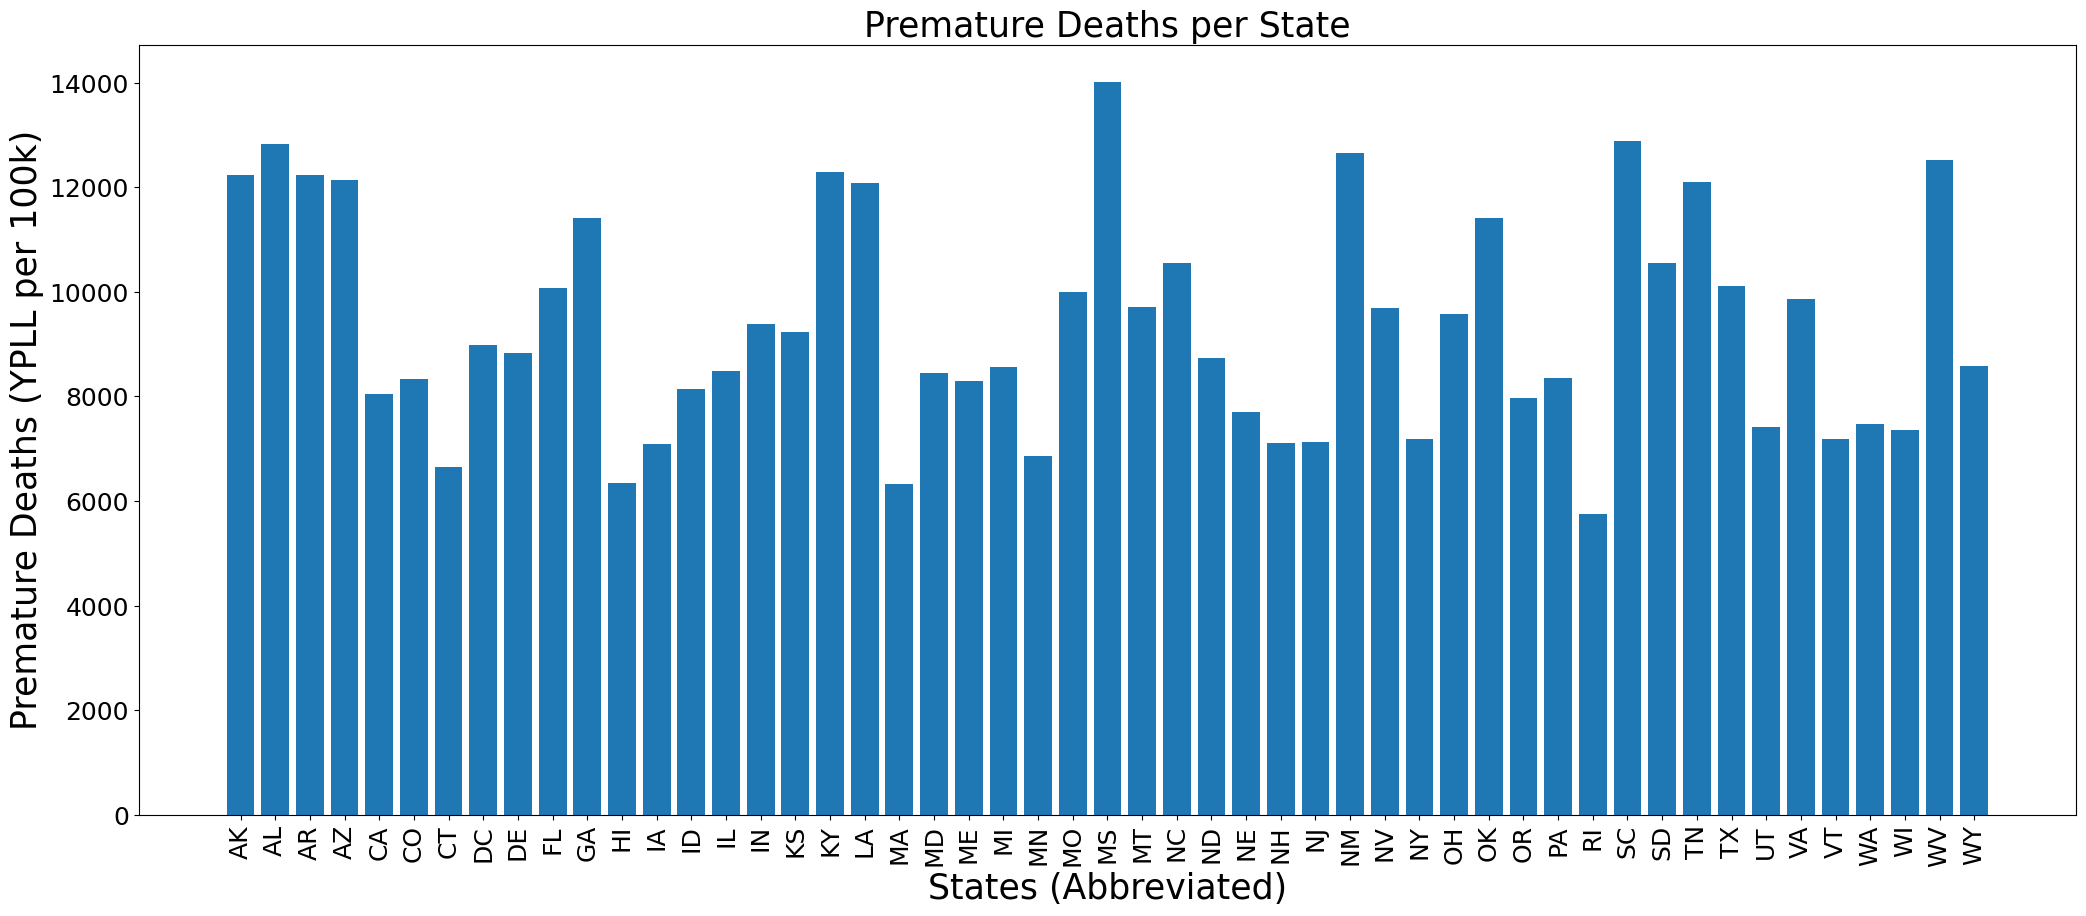

In [9]:
# this one is also free!
import matplotlib.pyplot as plt
state_death_data = data.groupby('State Abbreviation')['Premature Death raw value'].mean()

plt.figure(figsize=(25, 10)) # Set a wide width (18) and a standard height (6)
plt.bar(state_death_data.index, state_death_data.values)
plt.xticks(rotation=90)
plt.title("Premature Deaths per State", fontsize = 25)
plt.ylabel("Premature Deaths (YPLL per 100k)", fontsize = 25)
plt.xlabel("States (Abbreviated)", fontsize = 25)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show();

Graph Explanation: This bar graph is just to simply see which states suffer the most premature deaths (based off death average value). This information gives us a fantastic basis to see what we have to analyze and see potentially what these states have in common to lead to premature death, which in our eyes is one of the biggest defining data points in this set (considering there is nothing more permanent than death). Through this we can see that Mississippi, Alabama, New Mexico, South Carolina (and a few others) all have the highest premature death (per 100k people surveyed). There can be various connections, most of them are southern republican states, which could correlate to lack of healthcare, but they are also agricultural, etc. It gives us a jumping off point, hence why it's important to first analyze and to just get familiar with the data and a core variable that we are analyzing.

## Correlation Heatmap

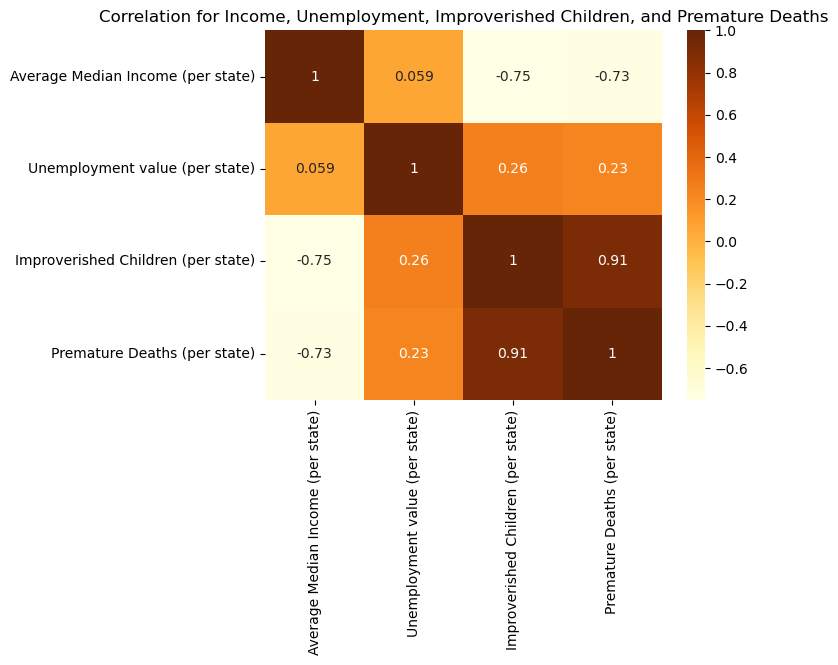

In [10]:
import seaborn as sns
average_median_income_data = data.groupby('State Abbreviation')['Median Household Income raw value'].mean().round(2)
                        
unemployment_data = data.groupby('State Abbreviation')['Unemployment raw value'].mean()
children_poverty_data = data.groupby('State Abbreviation')['Children in Poverty raw value'].mean()
additional_data = pd.DataFrame({
    'Average Median Income (per state)': average_median_income_data,
    'Unemployment value (per state)': unemployment_data,
    'Improverished Children (per state)': children_poverty_data,
    'Premature Deaths (per state)' : state_death_data
})
additional_data['Unemployment value (per state)'] = additional_data['Unemployment value (per state)'] * 100
additional_data['Improverished Children (per state)'] = additional_data['Improverished Children (per state)'] * 100

corr = additional_data[['Average Median Income (per state)', 'Unemployment value (per state)', 'Improverished Children (per state)', 'Premature Deaths (per state)']].corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='YlOrBr')
plt.title("Correlation for Income, Unemployment, Improverished Children, and Premature Deaths")
plt.show()


Graph Explanation: This graph takes four variables and finds a correlation matrix, where the darker the square and the closer the value to one, the higher the correlation. On the diagonals, logically, since it is comparing two identical data sets, there will be a ratio of 1 for similarity. The other dark squares show that the higher the unemployment rate, the more premature child deaths and the more impoverished children there will be. Additionally, the more impoverished children there are, the more premature deaths there will be. In context, the more states that have a low average median income are more likely to have a higher impoverished children percentage, which makes sense considering money is able to buy better living conditions and more sustainable areas for children to grow up, lowering the rate of poverty per higher income. The very surprising and interesting fact about this heatmap is that it demonstrates that unemployment does not really play a strong correlation to all of these other variables, especially average median income which is extremely surprising. Since usually being employed means you are likely to have a higher average income, but considering some people are stay at home parents, a one working household, or retired, I suppose it can make sense. It was just super intriguing to us, since we suspected that there would be a large, positive, strong, correlation of unemployment to poverty, income, and premature deaths, but there is not. Other than unemployment, everything has a strong correlation showing, at minimum, that the variables are likely connected to each other.

## Interactive Scatterplots

In [11]:
#PLEASE DOWNLOAD NOTEBOOK TO SEE THE INTERACTIVE PLOT
import plotly.express as px #for interactive plots (found package via Google Gemini) conda install -c conda-forge plotly
import numpy as np
access_Healthy_food_data = data.groupby('State Abbreviation')['Limited Access to Healthy Foods raw value'].mean()
housing_problems_data = data.groupby('State Abbreviation')['Severe Housing Problems raw value'].mean()
mammography_screen = data.groupby('State Abbreviation')['Mammography Screening raw value'].mean()

additional_data['Mammography Screening (%)'] = mammography_screen * 100
additional_data['Limited Healthy Food Access (%)'] = access_Healthy_food_data * 100
additional_data['Severe Housing Problems (%)'] = housing_problems_data * 100
additional_data = additional_data.rename(columns={
    'Average Median Income (per state)': 'Average Median Income ($)',
    'Unemployment value (per state)': 'Unemployment Rate (%)',
    'Improverished Children (per state)': 'Children in Poverty (%)',
    'Premature Deaths (per state)': 'Premature Deaths (YPLL per 100k)'

})
#to make state not just an index but a column (to categorize)
additional_data['State'] = additional_data.index

#For food access vs premature death
fig = px.scatter(
    additional_data,
    x='Limited Healthy Food Access (%)',
    y='Premature Deaths (YPLL per 100k)',

    hover_data=['State'],
    
    trendline='ols', # OLS (Ordinary Least Squares) is the standard linear regression
    trendline_color_override='red', 
    
    title='Interactive Regression: Food Access vs. Premature Deaths by State'
)

fig.update_traces(
    marker=dict(size=8, opacity=0.8, color='purple')
)
fig.update_layout(
    xaxis_title='Limited Healthy Food Access (%)',
    yaxis_title='Premature Deaths (YPLL per 100k)',
 
)

fig.show()

#For housing vs premature death
fig = px.scatter(
    additional_data,
    x='Severe Housing Problems (%)',
    y='Premature Deaths (YPLL per 100k)',

    hover_data=['State'],
    
    trendline='ols',
    trendline_color_override='red', 
    
    title='Interactive Regression: Housing Problems vs. Premature Deaths by State'
)

fig.update_traces(
    marker=dict(size=8, opacity=0.8, color='navy')
)
fig.update_layout(
    xaxis_title='Severe Housing Problems (%)',
    yaxis_title='Premature Deaths (YPLL per 100k)',
 
    showlegend=False
)

fig.show()

#For Mammography data
fig = px.scatter(
    additional_data,
    x='Mammography Screening (%)',
    y='Premature Deaths (YPLL per 100k)',

    hover_data=['State'],
    
    trendline='ols',
    trendline_color_override='red', 
    
    title='Interactive Regression: Mammography Screening vs. Premature Deaths by State'
)

fig.update_traces(
    marker=dict(size=8, opacity=0.8, color='orange')
)
fig.update_layout(
    xaxis_title='Mammography Screening (%)',
    yaxis_title='Premature Deaths (YPLL per 100k)',
 
    showlegend=False
)

fig.show()


These graphs help represent more than a few things which we find interesting and imperative to understand in terms of the data that we have been provided. Through these interactive scatterplots, with lines-of-bestfit, we are able to see a couple things for Limited Healthy Food Access V.S. Premature deaths (per 50 states and DC). We can see that it has a positive correlation where the harder it is to find or obtain healthy food, the more premature deaths there are. Which makes sense, if someone is more improvrished and finds it harder to eat healthy food (typically based on the overwhelming cost of healthy food), people in these areas will get less nutrients, causing more susceptibility to disease, illness, and death. It is clear to see this, through the scatterplot, since you can see the distribution of states and how they all go along this positively increasing line. 

The second graph actually tells the opposite side of the story, where we expect housing problems to impact premature deaths, due to lack of finances, living in dangerous neighborhoods, and living condtions all are related to premature deaths, but it in fact has almost no relation what so ever. One could even argue that it has a slight negative correlation to premature deaths, which would mean that the more severe ones housing problem is, the less likely they are to die prematurely. Which, quite frankly, goes against everything we have analyzed so far, which means that there will always be data and certain collections that are not what they appear to be. Sometimes what you would expect does not actually correlate or relate to others in the way you thought or at all. And in this case, we can see that housing problems are not that important or impactful when in terms of premature deaths. 

The third graph tells us something extremely important: the more access you have to healthcare the lower the premature deaths will end up being. This might be due to the fact of finances and being able to pay for better medicalcare or other outside influences, but what we have confirmed is that the more mammography screenings (screening for breast cancer) the lower the premature death value is. The negative slope demonstrates that, and it also has a correlation of 0.5 (hover over the line-of-bestfit). 

(If you hover on the datapoints it will illustrate important data and what states the data point refers to).

In [12]:
additional_data = additional_data.drop('State', axis=1)
additional_data

,Average Median Income ($),Unemployment Rate (%),Children in Poverty (%),Premature Deaths (YPLL per 100k),Mammography Screening (%),Limited Healthy Food Access (%),Severe Housing Problems (%)
State Abbreviation,,,,,,,
AK,77336.87,5.500367,16.576667,12230.366357,30.750000,14.413241,25.409486
AL,52610.94,2.978877,27.320896,12829.081699,38.477612,8.953997,12.051530
AR,49460.11,3.865420,26.136000,12241.687745,36.746667,11.306935,12.300412
AZ,60430.00,5.066805,21.946667,12145.585951,34.866667,16.431017,17.439632
CA,81425.50,4.837100,16.265517,8049.895792,36.431034,6.148599,21.416657
CO,72992.58,3.037877,15.787500,8324.071319,35.343750,8.626549,14.833371
CT,83967.75,4.058079,12.112500,6644.472566,46.500000,4.687929,15.464897
DC,99897.00,4.679161,20.000000,8975.956019,35.000000,1.606102,19.404797
DE,79493.67,4.674901,14.900000,8832.593757,50.333333,6.464245,14.284929


We just wanted to clean up the data table that we've been using for the graphs, isolating what we think are the most interesting and useful variables in the dataset. The only reason that we used a 'states' variable is because it we needed a categorical variable rather than using the index since there was too much work-around for it. Other than that, we also converted the raw value into percentages since it made it not only easier to understand and look at, since we see percents more often than raw value, but the values also look nicer and cleaner on a graph.

## 3. Asking the Hard Questions

By now we should know all of the ins and outs about this dataset (right?). Let's dive a little deeper into it and see if we can find anything interesting.

### Problem 4

As you worked through the initial data processing and understanding phase, did anything catch your interest? Let's formulate some questions and hypotheses that you could explore in depth.

**Write-up!** Formulate and describe a question you have/want to investigate. Then, formulate and describe a hypothesis that can (possibly) answer it. What inspired your idea (provide specifics from [the last section](#2.-Getting-Familiar-with-the-Data), if any)? How can you use the data to support or reject your hypothesis?

> **Hint**: Your question/hypothesis might be something that you are personally interested in or something that you think might lead to a product or service for users/customers. You might want to think about something that could help others in making decisions, etc.

*Grading Note: Your work will be graded for _creativity_. Be creative in the questions you ask/hypothesis you pose.* 

Do socioeconomic factors have significant impact on premature death? | Additional attatched sub-question: Does it differ more per state?

Alternative Hypothesis: We believe that socioeconomic factors have a significant impact on premature death, and certain states are more likely to have a higher premature death number due to the deficiency in socioeconomic factors.

Null Hypothesis: Socioeconomic factors do NOT have a significant impact on premature death, and state specific socioeconomic factors do not play an impactful role in premature death


While we looked and analyzed the data, we kept finding important socio-economic factors that are not only super impactful to people's wellbeing, but also very prevalent throughout the nation. And while looking at these socio-economic factors, such as healthy food access, severe housing problems, unemployment, and improverished children, we thought that they might explain trends in the premature death column. Which, to specify, stood out to us since there is nothing more final and holistic as death in life. So, naturally, that's the dependent variable that we really wanted to analyze and study. We use correlation heatmaps and scatterplots to show not only distribution of each state, but also the correlation of the states. A correlation heatmap directly demonstrates how interconnected our variables are to each other. importantly how they are connected to premature deaths. For the most part, our graphs were able to support our hypothesis demonstrating the inherent connection between premature death and impoverished children, median income, access to healthy foods, etc. But, to our surprise unemployment rates and severe housing problems had no impact on premature death viar correlation rate (0.23, 0.089 respectively). This could be used to reject our hypothesis considering these two socio-economic problems sound, at face value, like they variables that have a heavy impact on premature death. Unemployment did not even have any correlation to average median income per state (0.06), which was super intruiging because to make money you typically have to have a job. So, through the polling methods they might have asked stay at home parents, retired individuals, young adults who are from affluent families, etc, which makes it seem to have a less correlation than we would originally assume. But, even though severe housing problems and unemployment do not actually correlate or relate to premature deaths, it does not mean that our hypothesis is to be rejected. Overall, we have a lot of data collected, as we declare in later, from our other variables to push our hypothesis past those two obstacles. 


Assuming, for a moment, that our hypothesis is correct this can lead to a myriad of potential changes that can benefit our society. We can allocate more funds and attention towards cheaper healthy food, we can bring more attention to the impoverished children in our communities to draw out more help, raise the standard minimum wage in all states so people can live off those jobs. It just gives us more details on what we should utilize our research and money on in our local communities to make real changes, preventing and lowering premature rates. 

### Problem 5

**Do this!** Let's explore your hypothesis. Find evidence from the data that supports or refutes your hypothesis and present it — recall that as a data scientist, one of your goals is to discover and communicate your results to your audience, _me_. The more thorough your analysis, the better!

> **Hint**: Even though we focus on EDA here, you may include some predictive modeling here as well. 

Here's yet another _free_ cell; use as many as you need.

Writeup: As we can see from the data, specifically in the heatmap, there is a very strong (.91) relationship between impoverished children and premature deaths. This, in context, makes a lot of sense, since a poorer child is far more likely to not be able to afford top notch medical care, have access to healthy food, or have as much parental attention, since they have to work more to make a living. All of these factors for a young child are incredibly important for development, and a child who is not able to have all these needs tended to financially is more likely to pass prematurely. As well from the heatmap, we can see that average median income has a strong inverse relationship to premature deaths (-0.75). So, as median income grows, premature deaths decrease which is exactly what we suspected while reviewing the EDA's data set. The less money you have, the less potential access to healthy food, less healthcare benefits or someone simply can not pay for the care they recieve, etc. And whilst on the topic of healthcare, we can see through the mammography scatterplot that there is a clear and negative relationship between screenings and premature deaths. This is very similar to how the average median income is in terms that the more screenings one gets the less premature deaths there are. Having access and finances for healthcare is particularly important to study when determining premature deaths, to see if people are dying from very avoidable deaths. 


Additionally, as seen in the regression graph, there is a positive correlation between those with limited healthy food access and premature deaths, which only further reinforces the conclusion. The less access people have to healthy food, the more premature deaths there are. This may sound intuitive, but that is exactly the point. It is clear that this socioeconomic problem (not being able to afford, or have any transportation to get healthy food) is quite impactful on premature deaths, to a point where it bolsters our hypothesis. Not having access to healthy food is a reality that a lot of families around the U.S. suffer from, resorting to fast food, cheap food, or at times, no food. This data and analysis is not just to prove that there is a connection between socioeconomics and premature deaths, but it is to highlight the underrepresented and underhighlighted problems that families around the nation are facing and that we should allocate time and resources to resolving it. 


Through our findings, which we have also mentioned in 'Problem 4' briefly, is that there are some variables that we analyzed, suspecting a connection between it and premature death, but only to find out that they hold no weight on each other what-so-ever. These variables being severe housing problems and unemployment percentages throughout the nation. Though they might not have a strong correlation to premature death, it does give us helpful insight in on the socioeconomics relating to premature death. It helps us understand that not every single socioeconomic problem is going to be impactful, sometimes they are not inherently connected, but rather they are correlated in a different, less obvious way. And even if the EDA does not supply us with the potential data to retrieve that connection, it helps us realize that our biases and interpretations of society are not always going to be correct. It is a helpful tip that we, as Data Scientists, are not all knowing or free of personal bias, all we can do is mitigate it and do our best to catch our errors, like we do here.


Regarding what is stated above, it is clear that socioeconomic factors, such as healthcare, income, living situations, are impactful on premature death, causing death to occur when further in socioeconomic ruin. We can safely reject the null hypothesis, considering there is not enough evidence to support it, which means that our alternative hypothesis: " We believe that socioeconomic factors have a significant impact on premature death, and certain states are more likely to have a higher premature death number due to the defecient of socioeconomic factors", remains. Not that we have proved ourselves correct, but that this allows us to further research in the future and test our hypothesis at all angles.

### Problem 6

**Write up!** Did you find anything interesting in [Problem 5](#Problem-5)? If you did, tell me about it. If you don't think you found anything interesting, keep looking. 

> **Hint**: Provide links to key figures in your discussion. See [this StackOverflow question](https://stackoverflow.com/questions/28080066/how-to-reference-a-ipython-notebook-cell-in-markdown) for details.

**Answer here:** Something interesting and quite surprising is that, when looking for a visual correlation (found at [Interactive Scatterplots](#Interactive-Scatterplots)) between states with trouble accessing housing and premature deaths, there appeared to be no real correlation, and if anything, leaning slightly negative. This is surprising because you'd think that a child with an unstable housing situation would struggle to survive compared to one with secure housing and shelter, but the data does not indicate such. There are definitely states, such as Alaska, with high rates in both, but this is likely more due to the very drastic effects of the cold compared to a state like Hawaii, with high housing instability but low premature death rates. This also shows that, comparatively, housing appears to be less indicative of a child's chances of survival in early life compared to other, more developmentally important factors. 

Also, it was interesting how unemployment did not correlate to average median income AT ALL. The correlation was 0.062 which is just about as close to uncorrelated and unrelated as you can get. Which you can see through the [Correlation Heatmap](#Correlation-Heatmap) show above. This means that there is literally no connection between unemployment and income. It is just extremely interesting since we associate jobs with money, but there could be retired individuals or stay at home members in the family surveyed by the EDA making it lower than we expect. But, even with all those factors included it is still surprisingly low, making it one of the most interesting things we found in our research.

To quickly touch on an interesting fact we noticed about premature deaths per state, we noticed that more rural and southern states appeared to have more premature deaths. Taking a quick glance at [Staes Bar Graph](#States-to-Premature-Deaths-Bar-Graph), we can notice that states such as Arkansas, New Mexico, Nevada, Mississippi, and Alabama are all leading in premature deaths in the United States. We believe this has something to do with more rural areas where standards of living are different, and tend to be worse in certain areas (like healthcare and median income) than urbanized cities are. To help prove this, the interactive scatterplot of [Mammography to Premature Deaths](#Interactive-Scatterplots) (which helps represent/ illustrate the healthcare in the state) shows that states such as New Mexico, Nevada, and Arkansas has the least percentage of people going to get mammographies and also have the highest premature death rate because of it (top left of the scatterplot points). Helping represent that socio-econimic factors in specific states, which tend to be rural southern states, are going to affect the states amount of premature deaths.


### Problem 7
One last step that we shouldn't skip is reviewing both our data analysis approach and also the data acquisition method. 

**Write up!** Are there any shortcommings and/or **ethical issues** related to the way you used this data or formed your conclusions?
* Who are the stakeholders?
* How could someone other than yourself be impacted by any ethical issues arising from your analysis/work/product?
* Can you propose a way to resolve the issue(s)?

**Answer here:** There are definitely some shortcomings and ethical issues related to the way we used the data, not purposefully, but inherently due to the way that this data is formulated. First off, we are not sure as to how much of the data is from surveys, censuses, self-representation, etc. Which means we are not sure how representative this data is of the entire population. This could alter the truth and reliability of our findings if the data turns out to be non-representative. If the surveyers or talliers of the data are biased, the data which is being used is as well, and we want to stay as neutral and objective as possible, which gets negated. The stakeholders in the way we formatted the data are the people whose data is being distributed, us as the researchers, and those who review our findings. Someone other than us could be affected by the ethical dilemmas, because it may be someone's personal experiences we are unconsensually using to form a conclusion, which could be deemed offensive. Unfortunately, in that case, we are unable to resolve said ethical dilemma, as we are not the ones who are doing the surveys, but if someone asks for their data to be removed, we will do so hastily, so as to keep our data as ethically collected as possible. It may seem unfair to reduce thousands of people's lives and problems to numbers, but it is the only way we are properly able to analyze and find trends to help people in the future. It is a reality that we do not have the power to change. Another ethical issue that arose from our analysis was what we mentioned prior, about assuming a connection of severe housing problems and unemployment to premature death rates. It could be categorized as a cognitive bias, where we use our own systematic way of thinking and let it objectively dictate our research. But, we did catch ourselves through seeing the lack of correlational and connection via our heatmap and scatterplot, so we were able to squelch any personal ethical issue having an impact on our finished product.

Let's conclude with thinking about imporvements for the future! 

**Write up!** There are often times where the data you need doesn't exist (yet) and you need to go collect it. Based on your analysis of the data set, which features were informative and which weren't? What information that was missing from this dataset do you think would be helpful to have for next time?

**Answer here:** Overall, a vast majority of our data was informative, and that which wasn't would likely be directly correlated to a reseach question, with a correlation that can be directly found using the data. There are likely many datapoints that could be used for next time, but some notable ones could be obesity rate, whether or not a person is a drug user, or if the family has health insurance, since all of these are seemingly correlated to either a child's health, or a parent's ability to ensure that their child does not pass away prematurely 

### Problem 8

**Write up!** Did you use any generative AI tools (ChatGPT, Copilot, etc.) for this project?
* Which generative AI tools did you use?
* How did you them? 
* How did you ensure that your project reflects your own understanding?
* What challenges or adjustments did you encounter when using generative AI (refining prompts, verifying accuracy, revising outputs, etc.)?

**Answer here:** Our group did use generative AI, namely ChatGPT (GPT 4plus and 5), as well as Google Gemini (2.5 Flash). We tried to use GenAI as a tool to help us, rather than do the work for us. Due to our limited data science experience, but large dreams and aspirations for this project, we found some limitations as to what we could represent visually. We were able to clean the data using what we knew by hand, and intuitively made these percentages. However, we had trouble finding what to do for the interactive regression models, as we thought that it was imperative for us to be able to identify what outlying points matched respective states, and analyze other data in play there. In order to do this, we had to generate a rough outline and clean up syntax for the graph to work. Additionally, we ran some data through chatGPT to try to generate other metrics to use to find more links, but we did not end up using them, instead using metrics and associations we came up with organically. We made sure to keep ChatGPT as a debugging tool, not a codewriting tool that did the entire project for us. We also did all of these writeups organically, as we can interpret visual data ourselves, and it is a great exercise to further our knowledge of analyzing graphs we made ourselves. Some challenges we found using GenAI was that it would often use many packages and techniques that we have not covered in class, and we wanted to put forth a product which accurately shows what we know and how far we have come as students, not what GenAI can do. Overall though, we did a good job maintaining this balance, as we were able to excel at what we did know, learn more using GenAI to guide us, while not doing the whole project for us, and it did good in its limited application. 

And that's it! Remember to review your work and make sure it is well presented and organized. Not everyting you coded up needs to remain in your submission. **[Does [this cell] spark joy?](https://i.kinja-img.com/gawker-media/image/upload/s--iW_3HGbT--/c_scale,dpr_2.0,f_auto,fl_progressive,q_80,w_800/oruf4oavtj5vpmvaquew.jpg)** You are always trying to communicate your findings to somebody, _maybe even yourself_. 

> **Final Grading Note/Reminder**: Your work will be graded for _creativity_, _aesthetics_, _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report. Be creative in the questions you ask/hypothesis you pose as well as in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures. 

In [13]:
grader.check("hw6")

hw6 results: All test cases passed!

<!-- END QUESTION -->

